In [67]:
import pandas as pd
import matplotlib.pyplot as plt

```
GET: https://dukapp.com/.well-known/apple-app-site-association
RESPONSE: {
    "applinks": {
        "apps": [],
        "details": [
            {
                "appID": "TEAMID.BUNDLEID",
                "paths": [
                    "/invite/*",
                    "/reset/*",
                    "/magic/*"
                ]
            }
        ]
    }
}
```

```
GET https://dukapp.com/.well-known/assetlinks.json
RESPONSE: [
    {
        "relation": [
            "delegate_permission/common.handle_all_urls"
        ],
        "target": {
            "namespace": "android_app",
            "package_name": "com.dukapp.app",
            "sha256_cert_fingerprints": [
                "SHA256_AQUI"
            ]
        }
    }
]

```

In [68]:
df = pd.read_csv('student_placement_data.csv')

In [69]:
df.head()

,StudentID,Gender,MathScore,ReadingScore,WritingScore,AttendanceRate,HoursStudied,ParentalEducation,TestPreparationCourse,PlacementScore
0,S0016,Male,79.69,NaN,65.71,105.84,5.95,High School,Completed,66.59
1,S0010,Female,64.98,141.12,73.35,92.86,2.76,PhD,Completed,90.33
2,S0101,Male,70.13,12.67,42.91,102.58,3.62,Bachelor,NaN,44.73
3,S0133,Male,75.15,58.10,72.59,86.95,6.10,PhD,Completed,69.27
4,S0069,Female,72.60,40.46,40.02,88.83,8.27,Bachelor,Completed,53.18


In [70]:
df.shape

(205, 10)

In [71]:
df.duplicated().sum()

np.int64(5)

In [72]:
df = df.drop_duplicates()

In [73]:
nulls = df.isnull().sum()
nulls

StudentID                 0
Gender                    0
MathScore                15
ReadingScore             10
WritingScore              0
AttendanceRate            0
HoursStudied              0
ParentalEducation         0
TestPreparationCourse    95
PlacementScore            0
dtype: int64

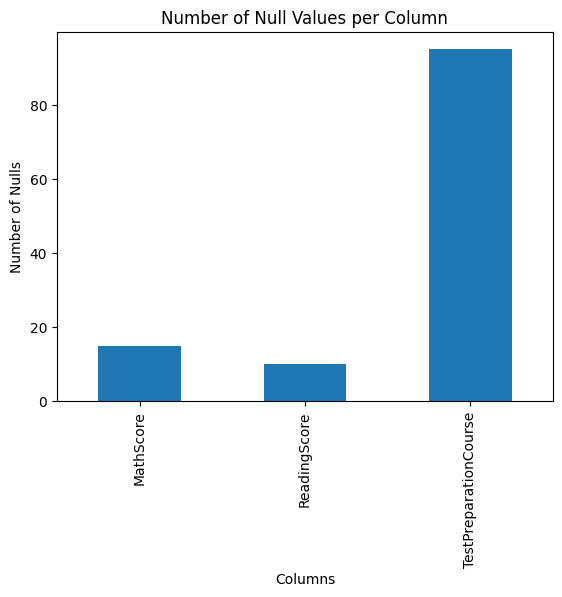

In [74]:
# histogram to visualize null values
nulls[nulls > 0].plot(kind='bar')
plt.title('Number of Null Values per Column')
plt.xlabel('Columns')
plt.ylabel('Number of Nulls')
plt.show()

Text(0.5, 0, 'Test Preparation Score')

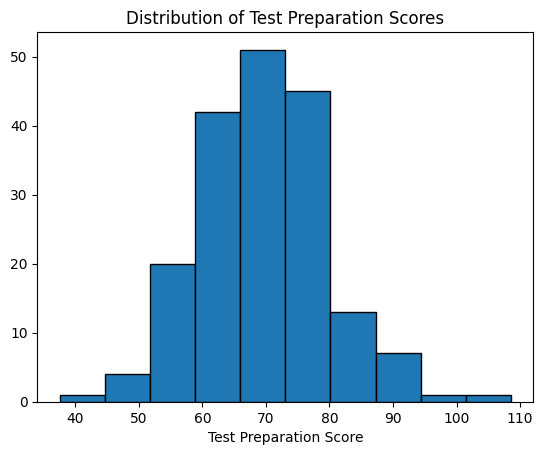

In [75]:
# Histogram TestPreparationScore
plt.hist(df['MathScore'].dropna(), bins=10, edgecolor='black')
plt.title('Distribution of Test Preparation Scores')
plt.xlabel('Test Preparation Score')

Text(0.5, 0, 'Test Preparation Score')

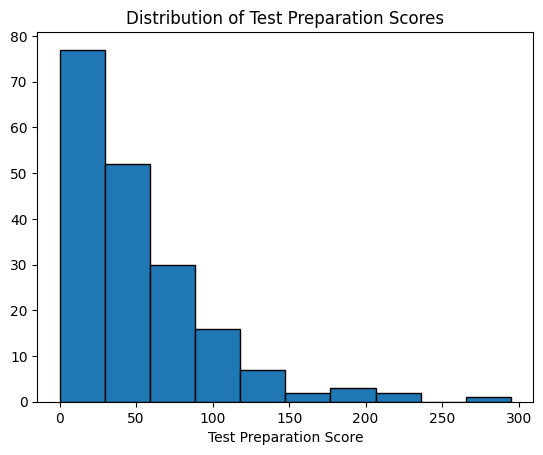

In [76]:
# Histogram TestPreparationScore
plt.hist(df['ReadingScore'].dropna(), bins=10, edgecolor='black')
plt.title('Distribution of Test Preparation Scores')
plt.xlabel('Test Preparation Score')

In [77]:
df["MathScore"] = df.groupby("Gender")["MathScore"].transform(lambda x: x.fillna(x.mean()))
df["ReadingScore"] = df.groupby("Gender")["ReadingScore"].transform(lambda x: x.fillna(x.median()))

In [78]:
# Detect outliers using IQR
Q1 = df['WritingScore'].quantile(0.25)
Q3 = df['WritingScore'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['WritingScore'] < lower_bound) | (df['WritingScore'] > upper_bound)]
outliers.shape

(8, 10)

In [79]:
df = df.fillna(df["TestPreparationCourse"].mode()[0])
df.head()

,StudentID,Gender,MathScore,ReadingScore,WritingScore,AttendanceRate,HoursStudied,ParentalEducation,TestPreparationCourse,PlacementScore
0,S0016,Male,79.69,32.70,65.71,105.84,5.95,High School,Completed,66.59
1,S0010,Female,64.98,141.12,73.35,92.86,2.76,PhD,Completed,90.33
2,S0101,Male,70.13,12.67,42.91,102.58,3.62,Bachelor,Completed,44.73
3,S0133,Male,75.15,58.10,72.59,86.95,6.10,PhD,Completed,69.27
4,S0069,Female,72.60,40.46,40.02,88.83,8.27,Bachelor,Completed,53.18


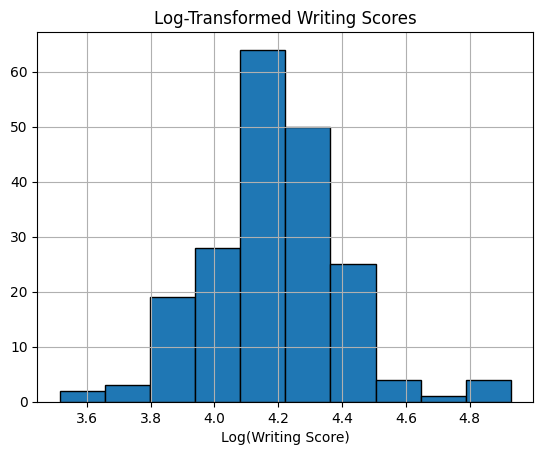

In [80]:
# Do option AOption A: Trimming.
df_A = df.copy()
df_A = df_A[(df_A['WritingScore'] >= lower_bound) & (df_A['WritingScore'] <= upper_bound)]
df_A.shape

# Do option AOption B: Log Transformation.
df_B = df.copy()
import numpy as np
df_B['WritingScore'] = np.log1p(df_B['WritingScore'])
df_B['WritingScore'].hist(bins=10, edgecolor='black')
plt.title('Log-Transformed Writing Scores')
plt.xlabel('Log(Writing Score)')
plt.show()


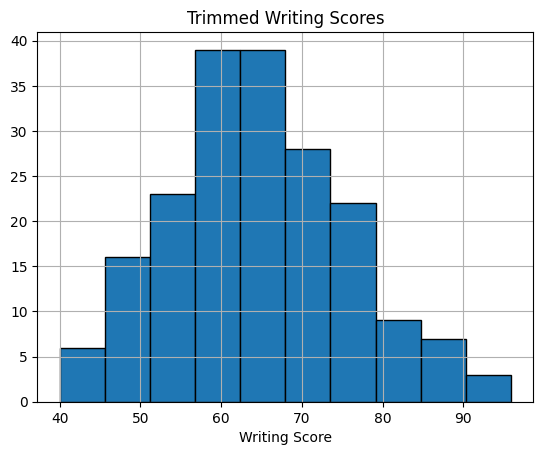

In [81]:
df_A['WritingScore'].hist(bins=10, edgecolor='black')
plt.title('Trimmed Writing Scores')
plt.xlabel('Writing Score')
plt.show()

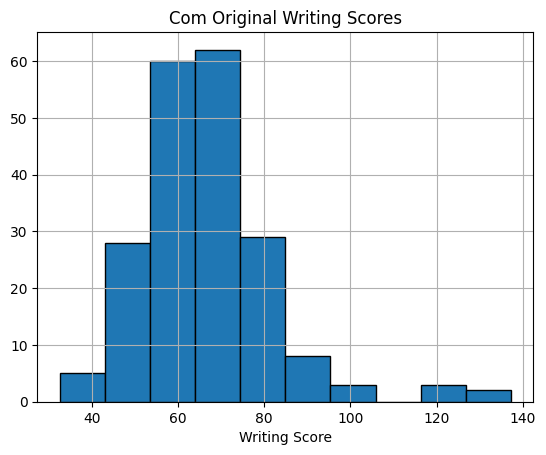

In [82]:
df['WritingScore'].hist(bins=10, edgecolor='black')
plt.title('Com Original Writing Scores')
plt.xlabel('Writing Score')
plt.show()

In [83]:
df.to_csv('student_placement_data_cleaned.csv', index=False)